# Annotation et découpage par cas

Objectif : obtenir les cas de triage à envoyer à Mistral, un seul exemplaire de chaque cas, puis (sections suivantes) les annoter et découper le dataset par cas.

## Dédoublonnage des cas de triage

On dédoublonne **avant d'annoter** : annoter deux fois le même patient coûte des appels pour rien, et les deux exemplaires pourraient finir dans deux splits différents.

Les cas de triage viennent de deux sources :

- **MediQAl** (français) : les cas cliniques des trois configs, anonymisés ;
- **UltraMedical-Preference** (anglais) : les prompts qui décrivent un patient (vignettes). Ce sont des QCM d'examen : on retire les choix A, B, C, D à la fin du texte, qui soufflent le diagnostic à l'annotateur, et on garde le cas et sa question. Les rares prompts dont les choix ne sont pas au format « A. » en début de ligne sont écartés.

FrenchMedMCQA et MedQuAD n'ont pas de cas de patient (QCM et questions de cours), elles ne sont pas annotées. Leurs doublons sont traités au découpage, plus bas.

On garde ceux qui passent le filtre `is_triage_case` (notebook 01), puis un seul cas par clé de cas : les 100 premiers caractères du texte normalisé. Dans chaque groupe, on garde le texte le plus court. C'est l'arrivée du patient, les textes plus longs ajoutent la suite de sa prise en charge (examens, évolution), ce qui ne doit pas servir au triage.

In [1]:
import sys
import warnings
from collections import defaultdict

sys.path.append("..")
# tqdm signale qu'ipywidgets manque (barres de progression) : sans effet sur les calculs
warnings.filterwarnings("ignore", message="IProgress not found")

import matplotlib.pyplot as plt
import pandas as pd

from scripts.cases import case_key, find_leaks, is_triage_case, remove_choices, split_cases
from scripts.extraction import (
    load_annotations, load_mediqal_cases, load_split_units, load_triage_cases, load_ultramedical_cases,
)
from src.visualizer import create_barplot, save_figure

In [2]:
cas_bruts = load_mediqal_cases() + load_ultramedical_cases()
cas_filtres = [r for r in cas_bruts if is_triage_case(r["cas"], r["langue"])]
cas_triage = load_triage_cases()

lignes = []
for source in ["mediqal", "ultramedical_preference"]:
    filtres = sum(r["source"] == source for r in cas_filtres)
    uniques = sum(r["source"] == source for r in cas_triage)
    lignes.append({
        "source": source,
        "textes": sum(r["source"] == source for r in cas_bruts),
        "cas de triage (filtre)": filtres,
        "doublons retirés": filtres - uniques,
        "cas à annoter": uniques,
    })
comptes = pd.DataFrame(lignes).set_index("source")
comptes.loc["total"] = comptes.sum()
comptes

,textes,cas de triage (filtre),doublons retirés,cas à annoter
source,,,,
mediqal,3074,2261,242,2019
ultramedical_preference,42709,13319,130,13189
total,45783,15580,372,15208


Le tableau se lit de gauche à droite : tous les textes de la source (pour UltraMedical, les prompts au format QCM), ceux qui passent le filtre de triage, les doublons retirés parmi eux, et ce qu'il reste à annoter.

Côté UltraMedical, le notebook 01 avait laissé une question ouverte : une même vignette revient-elle avec une question finale différente, comme les suites de cas de MediQAl ? Je regarde les groupes qui ont plusieurs textes.

In [3]:
groupes = defaultdict(list)
for record in cas_filtres:
    groupes[record["cle_cas"]].append(record)
doublons_ultramedical = [
    sorted(g, key=lambda r: len(r["cas"])) for g in groupes.values()
    if len(g) > 1 and g[0]["source"] == "ultramedical_preference"
]

# Trois exemples : le texte gardé et un texte retiré, autour de l'endroit où ils divergent
for groupe in doublons_ultramedical[:3]:
    a, b = groupe[0]["cas"], groupe[1]["cas"]
    diverge = next((k for k in range(min(len(a), len(b))) if a[k] != b[k]), min(len(a), len(b)))
    print(f"\ndivergent au caractère {diverge} :")
    print("  gardé  :", a[max(0, diverge - 60):diverge + 120])
    print("  retiré :", b[max(0, diverge - 60):diverge + 120])


divergent au caractère 102 :
  gardé  : and failure to thrive, Blood examination shows - Na = 122, K-6. He is most probably suffering from
  retiré : and failure to thrive, Blood examination shows - Na = 122, K - 6. He is most probably suffering from ?

divergent au caractère 228 :
  gardé  : tern with occasional erosive areas inside the lace pattern.
Histological feature will be
  retiré : tern with occasional erosive areas inside the lace pattern.
Syndrome associated with this disease is

divergent au caractère 227 :
  gardé  :  myocardial infarction. What will be the probable diagnosis -
  retiré :  myocardial infarction. What will be the probable diagnosis ?


Oui, UltraMedical a le même problème, mais rarement. Le tableau le montre : 130 doublons retirés sur 13 319 vignettes.

Les exemples ci dessus montrent d'où viennent ces doublons :

- la même vignette avec une autre question finale (le même patient, interrogé une fois sur l'histologie, une fois sur le syndrome associé) ;
- la même question recopiée, avec seulement la ponctuation qui change.

Dans les deux cas c'est le même patient, on ne l'annote qu'une fois.

Côté MediQAl, les 242 doublons retirés sont les suites de cas déjà vues au notebook 01 : le même patient, avec un paragraphe de plus.

**Limite.** La comparaison de texte trouve les doublons dans une même langue. Elle ne peut pas voir qu'un cas MediQAl en français et une vignette UltraMedical en anglais décrivent le même patient. Le risque est faible, les deux sources viennent d'examens différents (français d'un côté, américains et indiens de l'autre).

Répartition par langue des cas à annoter :

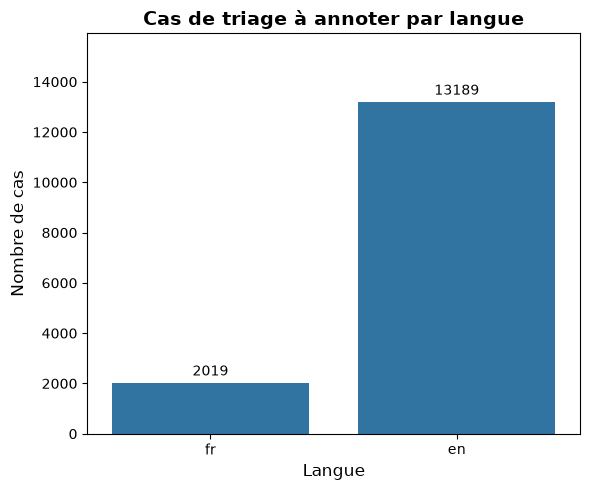

In [4]:
langues = pd.DataFrame([
    {"langue": langue, "n": sum(r["langue"] == langue for r in cas_triage)}
    for langue in ["fr", "en"]
])

fig, ax = plt.subplots(figsize=(6, 5))
create_barplot(
    langues, ax, x="langue", y="n",
    title="Cas de triage à annoter par langue",
    xlabel="Langue", ylabel="Nombre de cas",
    xrotation=0, fmt="{:.0f}",
)
plt.tight_layout()
save_figure(fig, "03_annotation_decoupage/cas_a_annoter_par_langue")
plt.show()

Les vignettes anglaises sont six fois et demie plus nombreuses que les cas français. Tout annoter déséquilibrerait fortement les langues. On annote donc tous les cas français et un tirage d'environ 3 300 vignettes anglaises, pour arriver à environ 5 000 cas de triage (40 % de français, 60 % d'anglais). La marge couvre les cas qui seront écartés après l'annotation, le filtre laissant passer du bruit.

## Niveaux d'urgence des cas annotés

L'annotation est faite par `scripts/annotation.py`, hors du notebook : elle prend du temps et chaque appel à Mistral est payant. Le notebook charge seulement le fichier produit.

Je regarde d'abord la répartition des trois niveaux dans chaque langue. C'est elle qui dira s'il faut rééquilibrer, et le découpage est stratifié dessus.

In [5]:
NIVEAUX = ["maximum", "moderate", "deferred"]

annotations = load_annotations()
niveaux = pd.crosstab(
    pd.Series([r["langue"] for r in annotations], name="langue"),
    pd.Series([r["urgency_level"] for r in annotations], name="niveau"),
)[NIVEAUX].loc[["fr", "en"]]
niveaux["total"] = niveaux.sum(axis=1)
niveaux.loc["total"] = niveaux.sum()
niveaux

niveau,maximum,moderate,deferred,total
langue,,,,
fr,1001,670,348,2019
en,1479,1021,796,3296
total,2480,1691,1144,5315


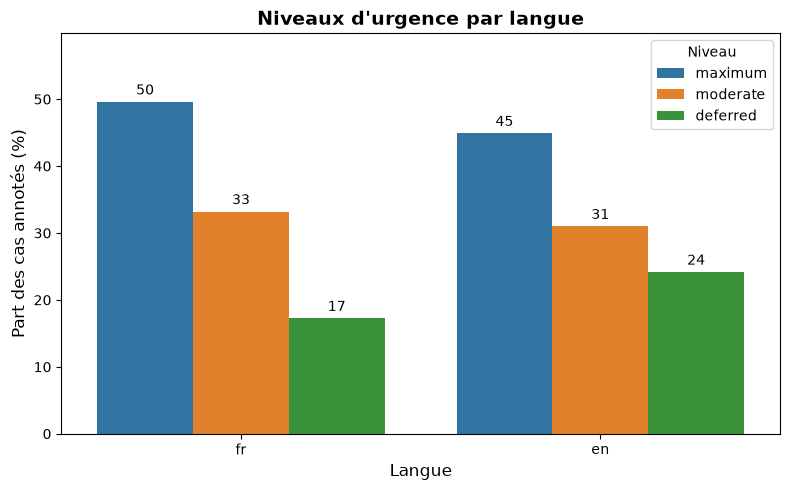

In [6]:
parts = niveaux.loc[["fr", "en"], NIVEAUX].div(niveaux.loc[["fr", "en"], "total"], axis=0) * 100
parts = parts.reset_index().melt(id_vars="langue", var_name="niveau", value_name="part")

fig, ax = plt.subplots(figsize=(8, 5))
create_barplot(
    parts, ax, x="langue", y="part", hue="niveau",
    title="Niveaux d'urgence par langue",
    xlabel="Langue", ylabel="Part des cas annotés (%)",
    xrotation=0, fmt="{:.0f}", show_legend=True, legend_title="Niveau",
)
plt.tight_layout()
save_figure(fig, "03_annotation_decoupage/niveaux_par_langue")
plt.show()

Côté français, l'annotation est complète : 2 019 cas, dont 1 001 `maximum` (50 %), 670 `moderate` (33 %) et 348 `deferred` (17 %). La moitié des cas en urgence maximale, c'est bien plus qu'aux urgences réelles. Ça vient de la source : MediQAl reprend des examens de médecine, qui choisissent des cas graves.

Côté anglais, les chiffres sont provisoires tant que les 3 300 vignettes ne sont pas toutes annotées. Elles sont tirées au hasard, la répartition ne devrait donc pas beaucoup bouger.

Dans les deux langues, `deferred` est la classe la plus rare. La décision de rééquilibrer ou non sera prise une fois l'annotation terminée.

## Découpage par cas

Le découpage est fait une seule fois, sur toutes les sources ensemble, avant de construire les exemples SFT et DPO. L'unité est la clé de cas, pas l'exemple : tous les textes qui partagent une clé vont dans le même split. C'est nécessaire parce qu'un même cas sert à plusieurs endroits :

- un cas MediQAl peut donner un exemple de triage et plusieurs questions ;
- une vignette UltraMedical annotée a aussi sa paire de préférences pour le DPO ;
- certains prompts UltraMedical sont des copies de questions MedQuAD.

Avec une seule clé pour tout, aucun de ces textes ne peut se retrouver à la fois dans le train et dans le test.

Ce qui entre dans le découpage (`load_split_units`) :

- les cas de triage annotés ;
- les questions MediQAl (clé : le cas clinique, ou la question s'il n'y en a pas) ;
- les questions FrenchMedMCQA et MedQuAD (clé : la question) ;
- tous les prompts UltraMedical-Preference (clé : le prompt).

`split_cases` répartit les clés en train (80 %), validation (10 %) et test (10 %). Le tirage est stratifié par source et, pour les cas annotés, par niveau d'urgence. Sans cette stratification, le test pourrait contenir très peu de `maximum`, et le rappel sur cette classe serait instable.

In [7]:
SPLITS = ["train", "validation", "test"]

unites = load_split_units()
splits = split_cases(unites)
# remplace aussi le split d'origine des sources qui en avaient un
for record in unites:
    record["split"] = splits[record["cle_cas"]]

# Une clé partagée par deux sources (MedQuAD et UltraMedical) est comptée dans la première
cles = pd.DataFrame(
    [{"cle_cas": r["cle_cas"], "source": r["source"], "split": r["split"]} for r in unites]
).drop_duplicates("cle_cas")
decoupage = pd.crosstab(cles["source"], cles["split"])[SPLITS]
decoupage.loc["total"] = decoupage.sum()
decoupage["part du test (%)"] = (decoupage["test"] / decoupage[SPLITS].sum(axis=1) * 100).round(1)
decoupage

split,train,validation,test,part du test (%)
source,,,,
frenchmedmcqa,854,106,107,10.0
mediqal,2504,314,313,10.0
medquad,11476,1434,1435,10.0
ultramedical_preference,50501,6313,6312,10.0
total,65335,8167,8167,10.0


Le tableau compte des clés de cas, pas des exemples. Chaque source garde à peu près les mêmes parts dans les trois splits. Les splits d'origine d'UltraMedical-Preference ne sont pas repris : le découpage global les remplace.

Le test de triage sera relu à la main et servira de vérité terrain. Je regarde combien de cas de chaque niveau il contient, par langue.

In [8]:
triage = pd.DataFrame([
    {"langue": r["langue"], "niveau": r["urgency_level"], "split": r["split"]}
    for r in unites if r.get("urgency_level")
])
triage_par_split = pd.crosstab([triage["langue"], triage["niveau"]], triage["split"])[SPLITS]
triage_par_split = triage_par_split.reindex(
    pd.MultiIndex.from_product([["fr", "en"], NIVEAUX], names=["langue", "niveau"])
)
triage_par_split.loc[("total", ""), :] = triage_par_split.sum()
triage_par_split.astype(int)

split            train  validation  test
langue niveau                           
fr     maximum     801         100   100
       moderate    536          67    67
       deferred    278          35    35
en     maximum    1183         148   148
       moderate    817         102   102
       deferred    637          80    79
total             4252         532   531

Les trois niveaux sont présents dans le test, dans les deux langues, avec les mêmes proportions que dans le train.

Ces chiffres changeront quand l'annotation sera complète. Le découpage est recalculé à chaque exécution, et la relecture du test ne commence qu'après.

## Contrôles

Deux vérifications sur le découpage :

- **Aucune clé de cas n'est dans deux splits.** C'est vrai par construction ici, puisque le split est attribué à la clé. Le même contrôle (`find_leaks`) est relancé sur les exemples SFT et DPO générés, où il a vraiment quelque chose à trouver.
- **Chaque paire de préférences est dans le même split que sa vignette.** La clé d'un cas annoté est calculée sur la vignette sans ses choix, celle d'une paire DPO sur le prompt entier. Tant que la vignette fait plus de 100 caractères, les deux clés sont identiques. Pour une vignette plus courte elles diffèrent, et la paire pourrait partir dans un autre split que le cas annoté.

In [9]:
fuites = find_leaks(unites)

# Pour chaque prompt UltraMedical, le split de sa vignette sans les choix, si sa clé est connue
paires_separees = []
for record in unites:
    if "prompt" not in record:
        continue
    vignette = remove_choices(record["prompt"])
    if vignette and splits.get(case_key(vignette), record["split"]) != record["split"]:
        paires_separees.append(record)

print(f"clés présentes dans plusieurs splits : {len(fuites)}")
print(f"paires DPO dans un autre split que leur vignette : {len(paires_separees)}")

clés présentes dans plusieurs splits : 0
paires DPO dans un autre split que leur vignette : 0


Les deux compteurs doivent être à zéro. Si le second ne l'est pas, il faudra calculer la clé des paires DPO sur la vignette sans ses choix, comme pour les cas annotés.